# Importación de las librerías necesarias para la ejecución #

In [72]:
#Librerias Necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import keras
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense
from keras import backend as K

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
#from sklearn.preprocessing import scale

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SelectFromModel

from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import confusion_matrix

from scipy.stats import f_oneway
from scipy.stats import kendalltau, spearmanr
from scipy.stats import pointbiserialr

# Lectura de los datos de los partidos ya formateados en .csv

In [73]:
import os

dataframes = []
carpeta = "Datos_Formateados/"  # Reemplaza "ruta/de/la/carpeta" con la ruta de la carpeta que deseas explorar

archivos = os.listdir(carpeta)
for archivo in archivos:
    df = pd.read_csv("Datos_Formateados/"+archivo)
    dataframes.append(df)
datos_partidos = pd.concat(dataframes, ignore_index=True)
datos_partidos.shape

with pd.ExcelWriter('Datos_Futbol_Completo.xlsx') as writer:
    archivos = os.listdir("Ejemplos/")
    i = 0
    for archivo in archivos:
        df = pd.read_csv("Ejemplos/"+archivo)
        df.to_excel(writer, sheet_name=f'Página {i+1}', index=False)
        i += 1

In [74]:
datos_partidos = datos_partidos.dropna()
datos_partidos.shape

(27937, 17)

In [75]:
datos_partidos.head()

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,HTHG,HTAG,HS,AS,HST,AST,HY,AY,HR,AR,FTR
0,D1,20/08/10,Bayern Munich,Wolfsburg,2.0,1.0,1.0,0.0,17.0,11.0,5.0,5.0,1.0,3.0,0.0,0.0,H
1,D1,21/08/10,FC Koln,Kaiserslautern,1.0,3.0,1.0,0.0,10.0,17.0,4.0,6.0,1.0,2.0,1.0,0.0,A
2,D1,21/08/10,Freiburg,St Pauli,1.0,3.0,0.0,0.0,9.0,17.0,3.0,7.0,0.0,0.0,0.0,0.0,A
3,D1,21/08/10,Hamburg,Schalke 04,2.0,1.0,0.0,0.0,18.0,13.0,6.0,4.0,2.0,0.0,0.0,1.0,H
4,D1,21/08/10,Hannover,Ein Frankfurt,2.0,1.0,1.0,1.0,13.0,17.0,7.0,3.0,0.0,1.0,0.0,0.0,H


In [76]:
def get_equipos(dataframe: pd.DataFrame) -> list:
    list = []
    for idx in dataframe.index:
        if dataframe['HomeTeam'][idx] not in list:
            list.append(dataframe['HomeTeam'][idx])
        if dataframe['AwayTeam'][idx] not in list:
            list.append(dataframe['AwayTeam'][idx])
    return list

equipos = get_equipos(dataframe=datos_partidos)
equipos

['Bayern Munich',
 'Wolfsburg',
 'FC Koln',
 'Kaiserslautern',
 'Freiburg',
 'St Pauli',
 'Hamburg',
 'Schalke 04',
 'Hannover',
 'Ein Frankfurt',
 'Hoffenheim',
 'Werder Bremen',
 "M'gladbach",
 'Nurnberg',
 'Dortmund',
 'Leverkusen',
 'Mainz',
 'Stuttgart',
 'Augsburg',
 'Hertha',
 'Fortuna Dusseldorf',
 'Greuther Furth',
 'Braunschweig',
 'Paderborn',
 'Darmstadt',
 'Ingolstadt',
 'RB Leipzig',
 'Union Berlin',
 'Bielefeld',
 'Bochum',
 'Heidenheim',
 'Aston Villa',
 'West Ham',
 'Blackburn',
 'Everton',
 'Bolton',
 'Fulham',
 'Chelsea',
 'West Brom',
 'Sunderland',
 'Birmingham',
 'Tottenham',
 'Man City',
 'Wigan',
 'Blackpool',
 'Wolves',
 'Stoke',
 'Liverpool',
 'Arsenal',
 'Man United',
 'Newcastle',
 'QPR',
 'Norwich',
 'Swansea',
 'Reading',
 'Southampton',
 'Cardiff',
 'Hull',
 'Crystal Palace',
 'Leicester',
 'Burnley',
 'Bournemouth',
 'Watford',
 'Middlesbrough',
 'Brighton',
 'Huddersfield',
 'Sheffield United',
 'Leeds',
 'Brentford',
 "Nott'm Forest",
 'Luton',
 'Auxer

# Predicción del ganador de un partido 

## - Pre-procesamiento de los datos ##

### Limpiado de valores de la columna FTR diferentes a [A,D,H]

In [77]:
condicion = (datos_partidos['FTR'] != 'A') & (datos_partidos['FTR'] != 'H') & (datos_partidos['FTR'] != 'D')
datos_partidos = datos_partidos.drop(datos_partidos[condicion].index)

### Obtención del gol average medio de cada partido

In [78]:
def get_goles_marcados_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_goles_por_partido = []
    partidos_del_equipo = dataframe.loc[(dataframe['HomeTeam'] == equipo) | (dataframe['AwayTeam'] == equipo)]
    for idx, partido in partidos_del_equipo.iterrows():
        if partido['HomeTeam'] == equipo:
            lista_goles_por_partido.append(partido['FTHG'])
        if partido['AwayTeam'] == equipo:
            lista_goles_por_partido.append(partido['FTAG'])
    return lista_goles_por_partido

def get_goles_encajados_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_goles_por_partido = []
    partidos_del_equipo = dataframe.loc[(dataframe['HomeTeam'] == equipo) | (dataframe['AwayTeam'] == equipo)]
    for idx, partido in partidos_del_equipo.iterrows():
        if partido['HomeTeam'] == equipo:
            lista_goles_por_partido.append(partido['FTAG'])
        if partido['AwayTeam'] == equipo:
            lista_goles_por_partido.append(partido['FTHG'])
    return lista_goles_por_partido

def obtencion_porteria_a_cero_dataframe(dataframe: pd.DataFrame, guardar: bool) -> list:
    lista_listas_porterias_a_0 = []
    equipos = get_equipos(dataframe=dataframe)
    for equipo in equipos:
        lista_porterias_a_0_por_equipo = []
        porterias_a_0 = 0
        lista_goles_encajados_por_partido = get_goles_encajados_por_partido(dataframe=dataframe, equipo=equipo)
        for goles_encajados in lista_goles_encajados_por_partido:
            if goles_encajados == 0:
                porterias_a_0 += 1
            lista_porterias_a_0_por_equipo.append(porterias_a_0)
        lista_porterias_a_0_por_equipo.insert(0,0)
        if guardar:
            dict_ultimo_porterias_a_0_equipo[equipo] = lista_porterias_a_0_por_equipo[-1]
        lista_porterias_a_0_por_equipo.pop()
        lista_listas_porterias_a_0.append(lista_porterias_a_0_por_equipo)
    return lista_listas_porterias_a_0

def get_tiros_a_puerta_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_tiros_por_partido = []
    partidos_del_equipo = dataframe.loc[(dataframe['HomeTeam'] == equipo) | (dataframe['AwayTeam'] == equipo)]
    for idx, partido in partidos_del_equipo.iterrows():
        if partido['HomeTeam'] == equipo:
            lista_tiros_por_partido.append(partido['HST'])
        if partido['AwayTeam'] == equipo:
            lista_tiros_por_partido.append(partido['AST'])
    return lista_tiros_por_partido

def get_media_tiros_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_tiros_por_partido = get_tiros_a_puerta_por_partido(dataframe=dataframe, equipo=equipo)
    lista_media_tiros_por_partido = []
    tiros_acumulados = 0
    for idx, valor in enumerate(lista_tiros_por_partido):
        lista_media_tiros_por_partido.append((valor + tiros_acumulados) / (idx+1))
        tiros_acumulados += valor
    return lista_media_tiros_por_partido

def obtencion_tiros_a_puerta_average_dataframe(dataframe: pd.DataFrame, guardar: bool) -> list:
    lista_listas_tiros_average_medio_cada_equipo = []
    equipos = get_equipos(dataframe=dataframe)
    for equipo in equipos:
        lista_tiros_average_medio_un_equipo = get_media_tiros_por_partido(dataframe=dataframe, equipo=equipo)
        lista_tiros_average_medio_un_equipo.insert(0,0)
        if guardar:
            dict_ultimo_tiros_medios_equipo[equipo] = lista_tiros_average_medio_un_equipo[-1]
        lista_tiros_average_medio_un_equipo.pop()
        lista_listas_tiros_average_medio_cada_equipo.append(lista_tiros_average_medio_un_equipo)
    return lista_listas_tiros_average_medio_cada_equipo

def get_media_goles_marcados_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_goles_por_partido = get_goles_marcados_por_partido(dataframe=dataframe, equipo=equipo)
    lista_media_goles_por_partido = []
    goles_acumulados = 0
    for idx, valor in enumerate(lista_goles_por_partido):
        lista_media_goles_por_partido.append((valor + goles_acumulados) / (idx+1))
        goles_acumulados += valor
    return lista_media_goles_por_partido

def get_media_goles_encajados_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_goles_por_partido = get_goles_encajados_por_partido(dataframe=dataframe, equipo=equipo)
    lista_media_goles_por_partido = []
    goles_acumulados = 0
    # añadir que si ve que el año de la temporada es distinto a uno previo goles acumulados = 0 para que cada temporada se reinicie
    for idx, valor in enumerate(lista_goles_por_partido):
        lista_media_goles_por_partido.append((valor + goles_acumulados) / (idx+1))
        goles_acumulados += valor
    return lista_media_goles_por_partido

def get_media_gol_average_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_goles_marcados_por_partido = get_goles_marcados_por_partido(dataframe=dataframe, equipo=equipo)
    lista_goles_encajados_por_partido = get_goles_encajados_por_partido(dataframe=dataframe, equipo=equipo)
    lista_media_gol_average_por_partido = []
    valor_acumulado = 0
    for idx, valor in enumerate(lista_goles_marcados_por_partido):
        lista_media_gol_average_por_partido.append((valor - lista_goles_encajados_por_partido[idx] + valor_acumulado) / (idx+1))
        valor_acumulado += (valor - lista_goles_encajados_por_partido[idx])
    return lista_media_gol_average_por_partido

def obtencion_gol_average_dataframe(dataframe: pd.DataFrame, guardar: bool) -> list:
    lista_listas_gol_average_medio_cada_equipo = []
    equipos = get_equipos(dataframe=dataframe)
    for equipo in equipos:
        lista_gol_average_medio_un_equipo = get_media_gol_average_por_partido(dataframe=dataframe, equipo=equipo)
        lista_gol_average_medio_un_equipo.insert(0,0)
        if guardar:
            dict_ultimo_gol_average_equipo[equipo] = lista_gol_average_medio_un_equipo[-1]
        lista_gol_average_medio_un_equipo.pop()
        lista_listas_gol_average_medio_cada_equipo.append(lista_gol_average_medio_un_equipo)
    return lista_listas_gol_average_medio_cada_equipo
        
def get_diferencia_media_gol_average_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_media_gol_average_por_partido = get_media_gol_average_por_partido(dataframe=dataframe, equipo=equipo)
    lista_diferencias = []
    valor_anterior = 0
    for valor in lista_media_gol_average_por_partido:
        lista_diferencias.append(valor - valor_anterior)
        valor_anterior = valor
    return lista_diferencias

def obtencion_diferencias_average_dataframe(dataframe: pd.DataFrame, guardar: bool) -> list:
    lista_listas_diferencias_gol_average_medio_cada_equipo = []
    equipos = get_equipos(dataframe=dataframe)
    for equipo in equipos:
        lista_diferencias_gol_average_medio_un_equipo = get_diferencia_media_gol_average_por_partido(dataframe=dataframe, equipo=equipo)
        lista_diferencias_gol_average_medio_un_equipo.insert(0,0)
        if guardar:
            dict_ultimas_diferencias_cada_equipo[equipo] = lista_diferencias_gol_average_medio_un_equipo[-1]
        lista_diferencias_gol_average_medio_un_equipo.pop()
        lista_listas_diferencias_gol_average_medio_cada_equipo.append(lista_diferencias_gol_average_medio_un_equipo)
    return lista_listas_diferencias_gol_average_medio_cada_equipo
        
def get_tarjetas_rojas_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_rojas_por_partido = []
    partidos_del_equipo = dataframe.loc[(dataframe['HomeTeam'] == equipo) | (dataframe['AwayTeam'] == equipo)]
    for idx, partido in partidos_del_equipo.iterrows():
        if partido['HomeTeam'] == equipo:
            lista_rojas_por_partido.append(partido['HR'])
        if partido['AwayTeam'] == equipo:
            lista_rojas_por_partido.append(partido['AR'])
    return lista_rojas_por_partido

def get_media_rojas_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_tarjetas_rojas_por_partido = get_tarjetas_rojas_por_partido(dataframe=dataframe, equipo=equipo)
    lista_media_tarjetas_rojas_por_partido = []
    valor_acumulado = 0
    for idx, valor in enumerate(lista_tarjetas_rojas_por_partido):
        lista_media_tarjetas_rojas_por_partido.append((valor + valor_acumulado) / (idx+1))
        valor_acumulado += valor
    return lista_media_tarjetas_rojas_por_partido

def obtencion_rojas_average_dataframe(dataframe: pd.DataFrame, guardar: bool) -> list:
    lista_listas_rojas_por_partido_cada_equipo = []
    equipos = get_equipos(dataframe=dataframe)
    for equipo in equipos:
        lista_rojas_por_partido_un_equipo = get_media_rojas_por_partido(dataframe=dataframe, equipo=equipo)
        lista_rojas_por_partido_un_equipo.insert(0,0)
        if guardar:
            dict_ultimas_rojas_cada_equipo[equipo] = lista_rojas_por_partido_un_equipo[-1]
        lista_rojas_por_partido_un_equipo.pop()
        lista_listas_rojas_por_partido_cada_equipo.append(lista_rojas_por_partido_un_equipo)
    return lista_listas_rojas_por_partido_cada_equipo

def get_puntos_en_liga_equipo(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_puntos_por_partido = []
    puntos = 0
    partidos_equipo = dataframe.loc[(dataframe['HomeTeam'] == equipo) | (dataframe['AwayTeam'] == equipo)]
    for idx, partido in partidos_equipo.iterrows():
        resultado = partido['FTR']
        if partido['HomeTeam'] == equipo and resultado == 'H':
           puntos += 3 
        elif partido['AwayTeam'] == equipo and resultado == 'A':
           puntos += 3
        elif resultado == 'D':
           puntos += 1
        else:
            puntos += 0
        lista_puntos_por_partido.append(puntos)
    return lista_puntos_por_partido

def get_resultados_partidos_equipo(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_resultados_equipo = []
    victorias = 0
    empates = 0
    derrotas = 0
    partidos_del_equipo = dataframe.loc[(dataframe['HomeTeam'] == equipo) | (dataframe['AwayTeam'] == equipo)]
    for idx, partido in partidos_del_equipo.iterrows():
        if partido['HomeTeam'] == equipo and partido['FTR'] == 'H':
            victorias += 1
        elif partido['AwayTeam'] == equipo and partido['FTR'] == 'A':
            victorias += 1
        elif partido['HomeTeam'] == equipo and partido['FTR'] == 'A':
            derrotas += 1
        elif partido['AwayTeam'] == equipo and partido['FTR'] == 'H':
            derrotas += 1
        else:
            empates += 1
        lista_resultados_equipo.append((victorias,empates,derrotas))
    return lista_resultados_equipo

def obtencion_resultados_en_liga(dataframe: pd.DataFrame, guardar: bool) -> list:
    lista_listas_resultados_en_liga = []
    equipos = get_equipos(dataframe=dataframe)
    for equipo in equipos:
        lista_resultados_por_partido_un_equipo = get_resultados_partidos_equipo(dataframe=dataframe, equipo=equipo)
        lista_resultados_por_partido_un_equipo.insert(0,(0,0,0))
        if guardar:
            dict_ultimos_resultados_cada_equipo[equipo] = lista_resultados_por_partido_un_equipo[-1]
        lista_resultados_por_partido_un_equipo.pop()
        lista_listas_resultados_en_liga.append(lista_resultados_por_partido_un_equipo)
    return lista_listas_resultados_en_liga

def obtencion_puntos_en_liga(dataframe: pd.DataFrame, guardar:bool) -> list:
    lista_listas_puntos_en_liga = []
    equipos = get_equipos(dataframe=dataframe)
    for equipo in equipos:
        lista_puntos_por_partido_un_equipo = get_puntos_en_liga_equipo(dataframe=dataframe, equipo=equipo)
        lista_puntos_por_partido_un_equipo.insert(0,0)
        if guardar:
            dict_ultimos_puntos_cada_equipo[equipo] = lista_puntos_por_partido_un_equipo[-1]
        lista_puntos_por_partido_un_equipo.pop()
        lista_listas_puntos_en_liga.append(lista_puntos_por_partido_un_equipo)
    return lista_listas_puntos_en_liga
    
def obtencion_media_goles_marcados(dataframe: pd.DataFrame, guardar:bool) -> list:
    lista_listas_goles_marcados = []
    equipos = get_equipos(dataframe=dataframe)
    for equipo in equipos:
        lista_goles_por_partido_un_equipo = get_media_goles_marcados_por_partido(dataframe=dataframe, equipo=equipo)
        lista_goles_por_partido_un_equipo.insert(0,0)
        if guardar:
            dict_ultimos_goles_marcados_cada_equipo[equipo] = lista_goles_por_partido_un_equipo[-1]
        lista_goles_por_partido_un_equipo.pop()
        lista_listas_goles_marcados.append(lista_goles_por_partido_un_equipo)
    return lista_listas_goles_marcados
    
def insercion_datos_cada_dataframe(dataframe: pd.DataFrame, lista_listas_gol_average_medio_cada_equipo: list, lista_listas_diferencias_gol_average_medio_cada_equipo: list,
lista_listas_rojas_por_partido_cada_equipo: list, lista_listas_puntos_por_partido: list, lista_listas_goles_marcados_por_partido: list,
lista_listas_resultados_por_partido: list, lista_listas_porterias_a_cero: list, lista_listas_tiros_medios_por_partido: list):
    equipos = get_equipos(dataframe=dataframe)
    for idx_equipos,equipo in enumerate(equipos):
        partidos_del_equipo = dataframe.loc[(dataframe['HomeTeam'] == equipo) | (dataframe['AwayTeam'] == equipo)]
        idx_partidos = 0
        for idx, partido in partidos_del_equipo.iterrows():
            if partido['HomeTeam'] == equipo:
                dataframe.at[idx,'Gol_Average_Home'] = lista_listas_gol_average_medio_cada_equipo[idx_equipos][idx_partidos]
                dataframe.at[idx,'Dif_Home'] = lista_listas_diferencias_gol_average_medio_cada_equipo[idx_equipos][idx_partidos]
                dataframe.at[idx,'Rojas_Home'] = lista_listas_rojas_por_partido_cada_equipo[idx_equipos][idx_partidos]
                dataframe.at[idx,'Puntos_Home'] = lista_listas_puntos_por_partido[idx_equipos][idx_partidos]
                dataframe.at[idx,'Goles_Marcados_Home'] = lista_listas_goles_marcados_por_partido[idx_equipos][idx_partidos]
                dataframe.at[idx,'Victorias_Home'] = lista_listas_resultados_por_partido[idx_equipos][idx_partidos][0]
                dataframe.at[idx,'Empates_Home'] = lista_listas_resultados_por_partido[idx_equipos][idx_partidos][1]
                dataframe.at[idx,'Derrotas_Home'] = lista_listas_resultados_por_partido[idx_equipos][idx_partidos][2]
                dataframe.at[idx,'Porterias_0_Home'] = lista_listas_porterias_a_cero[idx_equipos][idx_partidos]
                dataframe.at[idx,'Tiros_Home'] = lista_listas_tiros_medios_por_partido[idx_equipos][idx_partidos]
            if partido['AwayTeam'] == equipo:
                dataframe.at[idx,'Gol_Average_Away'] = lista_listas_gol_average_medio_cada_equipo[idx_equipos][idx_partidos]
                dataframe.at[idx,'Dif_Away'] = lista_listas_diferencias_gol_average_medio_cada_equipo[idx_equipos][idx_partidos]
                dataframe.at[idx,'Rojas_Away'] = lista_listas_rojas_por_partido_cada_equipo[idx_equipos][idx_partidos]
                dataframe.at[idx,'Puntos_Away'] = lista_listas_puntos_por_partido[idx_equipos][idx_partidos]
                dataframe.at[idx,'Goles_Marcados_Away'] = lista_listas_goles_marcados_por_partido[idx_equipos][idx_partidos]
                dataframe.at[idx,'Victorias_Away'] = lista_listas_resultados_por_partido[idx_equipos][idx_partidos][0]
                dataframe.at[idx,'Empates_Away'] = lista_listas_resultados_por_partido[idx_equipos][idx_partidos][1]
                dataframe.at[idx,'Derrotas_Away'] = lista_listas_resultados_por_partido[idx_equipos][idx_partidos][2]
                dataframe.at[idx,'Porterias_0_Away'] = lista_listas_porterias_a_cero[idx_equipos][idx_partidos]
                dataframe.at[idx,'Tiros_Away'] = lista_listas_tiros_medios_por_partido[idx_equipos][idx_partidos]
            idx_partidos += 1
    return dataframe    
    
dict_ultimas_diferencias_cada_equipo = {}    
dict_ultimo_gol_average_equipo = {}
dict_ultimas_rojas_cada_equipo = {}
dict_ultimos_puntos_cada_equipo = {}
dict_ultimos_goles_marcados_cada_equipo = {}
dict_ultimos_resultados_cada_equipo = {}
dict_ultimo_porterias_a_0_equipo = {}
dict_ultimo_tiros_medios_equipo = {}
guardar=False
numero = 1
for idx,temporada in enumerate(dataframes):
    if idx == (len(dataframes) - 1):
        guardar = True
    lista_listas_gol_average_medio_cada_equipo = obtencion_gol_average_dataframe(dataframe=temporada, guardar=guardar)
    lista_listas_diferencias_gol_average_medio_cada_equipo = obtencion_diferencias_average_dataframe(dataframe=temporada, guardar=guardar)
    lista_media_tarjetas_rojas_por_partido = obtencion_rojas_average_dataframe(dataframe=temporada, guardar=guardar)
    lista_listas_puntos_por_partido = obtencion_puntos_en_liga(dataframe=temporada, guardar=guardar)
    lista_listas_goles_marcados_por_partido = obtencion_media_goles_marcados(dataframe=temporada, guardar=guardar)
    lista_listas_resultados_por_partido = obtencion_resultados_en_liga(dataframe=temporada, guardar=guardar)
    lista_listas_porterias_a_cero = obtencion_porteria_a_cero_dataframe(dataframe=temporada, guardar=guardar)
    lista_listas_tiros_medios_por_partido = obtencion_tiros_a_puerta_average_dataframe(dataframe=temporada, guardar=guardar)

    dataframe_con_datos_temporada = insercion_datos_cada_dataframe(dataframe=temporada, lista_listas_gol_average_medio_cada_equipo=lista_listas_gol_average_medio_cada_equipo,
                lista_listas_diferencias_gol_average_medio_cada_equipo=lista_listas_diferencias_gol_average_medio_cada_equipo,
                lista_listas_rojas_por_partido_cada_equipo=lista_media_tarjetas_rojas_por_partido,
                lista_listas_puntos_por_partido=lista_listas_puntos_por_partido,
                lista_listas_goles_marcados_por_partido=lista_listas_goles_marcados_por_partido,
                lista_listas_resultados_por_partido=lista_listas_resultados_por_partido,
                lista_listas_porterias_a_cero=lista_listas_porterias_a_cero,
                lista_listas_tiros_medios_por_partido = lista_listas_tiros_medios_por_partido)
    dataframes[idx] = dataframe_con_datos_temporada

    #dataframe_con_datos_temporada.to_csv("Ejemplos/Datos_futbol_"+str(numero)+".csv")
    numero += 1
    
datos_partidos = pd.concat(dataframes)
    
print(dict_ultimo_tiros_medios_equipo)
print(len(dict_ultimo_tiros_medios_equipo))

##NO PILLA LOS ULTIMOS DATOS DE TODAS LAS LIGAS

{'Almeria': 4.0, 'Vallecano': 4.233333333333333, 'Sevilla': 4.433333333333334, 'Valencia': 3.533333333333333, 'Sociedad': 4.233333333333333, 'Girona': 4.933333333333334, 'Las Palmas': 3.2666666666666666, 'Mallorca': 3.533333333333333, 'Ath Bilbao': 4.7, 'Real Madrid': 6.366666666666666, 'Celta': 3.966666666666667, 'Osasuna': 3.433333333333333, 'Villarreal': 4.5, 'Betis': 3.8333333333333335, 'Getafe': 4.2, 'Barcelona': 6.033333333333333, 'Cadiz': 3.033333333333333, 'Alaves': 3.5, 'Ath Madrid': 5.766666666666667, 'Granada': 3.8333333333333335}
20


### Asignación de etiquetas numéricas a los posibles valores de FTR, HomeTeam y AwayTeam

In [79]:
lb_make = LabelEncoder()
datos_partidos['target FTR'] = lb_make.fit_transform(datos_partidos['FTR'])
datos_partidos['FTR'].value_counts()
label_encoder = LabelEncoder()
datos_partidos['labeled Home'] = label_encoder.fit_transform(datos_partidos['HomeTeam'])
datos_partidos['labeled Away'] = label_encoder.fit_transform(datos_partidos['AwayTeam'])

In [80]:
datos_partidos['FTR'].value_counts()

FTR
H    12496
A     8417
D     7028
Name: count, dtype: int64

In [81]:
datos_partidos['target FTR'].value_counts()

target FTR
2    12496
0     8417
1     7028
3        8
Name: count, dtype: int64

In [82]:
condicion = (datos_partidos['target FTR'] == 3)
datos_partidos = datos_partidos.drop(datos_partidos[condicion].index)
datos_partidos = datos_partidos.dropna()
datos_partidos['target FTR'].value_counts()

target FTR
2    12457
0     8393
1     7010
Name: count, dtype: int64

In [83]:
datos_locales = datos_partidos.loc[datos_partidos['FTR'] == 'H']  # Obtiene los índices de las primeras 100 filas que cumplen la condición
datos_empates = datos_partidos.loc[datos_partidos['FTR'] == 'D']  # Obtiene los índices de las primeras 100 filas que cumplen la condición
datos_visitantes = datos_partidos.loc[datos_partidos['FTR'] == 'A']  # Obtiene los índices de las primeras 100 filas que cumplen la condición
print(len(datos_locales))
print(len(datos_empates))
print(len(datos_visitantes))

dataframes = [datos_empates,datos_visitantes.head(7050), datos_locales.head(7090)]
datos_partidos = pd.concat(dataframes)
datos_partidos = datos_partidos.drop_duplicates()
datos_partidos['FTR'].value_counts()


12457
7010
8393


FTR
H    8410
A    8393
Name: count, dtype: int64

In [84]:
datos_partidos.head()

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,HTHG,HTAG,HS,AS,...,Puntos_Away,Goles_Marcados_Away,Victorias_Away,Empates_Away,Derrotas_Away,Porterias_0_Away,Tiros_Away,target FTR,labeled Home,labeled Away
1,D1,21/08/10,FC Koln,Kaiserslautern,1.0,3.0,1.0,0.0,10.0,17.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,65,93
2,D1,21/08/10,Freiburg,St Pauli,1.0,3.0,0.0,0.0,9.0,17.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,68,170
7,D1,22/08/10,Dortmund,Leverkusen,0.0,2.0,0.0,2.0,14.0,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,54,105
10,D1,28/08/10,Ein Frankfurt,Hamburg,1.0,3.0,1.0,0.0,12.0,14.0,...,3.0,2.0,1.0,0.0,0.0,0.0,6.0,0,59,77
11,D1,28/08/10,Nurnberg,Freiburg,1.0,2.0,1.0,1.0,17.0,5.0,...,0.0,1.0,0.0,0.0,1.0,0.0,3.0,0,136,68


### Dividir el dataframe en 2 para coger empates y visitantes de uno

In [85]:
'''
mitad = len(datos_partidos) // 2

datos_partidos_empates_visitantes = datos_partidos.iloc[:mitad]
datos_partidos = datos_partidos.iloc[mitad:]

datos_empates = datos_partidos_empates_visitantes[datos_partidos_empates_visitantes['FTR'] == 'D'].head(500)
datos_visitantes = datos_partidos_empates_visitantes[datos_partidos_empates_visitantes['FTR'] == 'A'].head(500)
#datos_locales = datos_partidos_empates_visitantes[datos_partidos_empates_visitantes['FTR'] == 'H'].head(200)

dataframes = [datos_partidos, datos_empates, datos_visitantes]

datos_partidos = pd.concat(dataframes)
datos_partidos = datos_partidos.drop_duplicates()

conteo_resultados = datos_partidos['FTR'].value_counts()

print(conteo_resultados)
'''

"\nmitad = len(datos_partidos) // 2\n\ndatos_partidos_empates_visitantes = datos_partidos.iloc[:mitad]\ndatos_partidos = datos_partidos.iloc[mitad:]\n\ndatos_empates = datos_partidos_empates_visitantes[datos_partidos_empates_visitantes['FTR'] == 'D'].head(500)\ndatos_visitantes = datos_partidos_empates_visitantes[datos_partidos_empates_visitantes['FTR'] == 'A'].head(500)\n#datos_locales = datos_partidos_empates_visitantes[datos_partidos_empates_visitantes['FTR'] == 'H'].head(200)\n\ndataframes = [datos_partidos, datos_empates, datos_visitantes]\n\ndatos_partidos = pd.concat(dataframes)\ndatos_partidos = datos_partidos.drop_duplicates()\n\nconteo_resultados = datos_partidos['FTR'].value_counts()\n\nprint(conteo_resultados)\n"

### Definición de los predictores y del objetivo de predicción ###
| Variable | Descripción
| :-------- | :-------:
| HomeTeam | Nombre del equipo local
| AwayTeam | Nombre del equipo visitante
| Gol_Average_Home | Gol Average medio del equipo local hasta el partido que se juega
| Gol_Average_Away | Gol Average medio del equipo visitante hasta el partido que se juega
| Dif_Home | Diferencia entre el Gol Average medio del local de los dos últimos partidos
| Dif_Away | Diferencia entre el Gol Average medio del visitante de los dos últimos partidos
| Rojas_Home | Media de rojas del equipo local
| Rojas_Away | Media de rojas del equipo visitante
| FTR | Ganador del partido (Home, Draw, Away)
| target FTR | Ganador del partido (2, 1, 0)

In [86]:
equipos_locales = datos_partidos['labeled Home']
equipos_visitantes = datos_partidos['labeled Away']
gol_average_home = datos_partidos['Gol_Average_Home']
gol_average_away = datos_partidos['Gol_Average_Away']
gol_averages = datos_partidos[['Gol_Average_Home','Gol_Average_Away']]
diferencia_home = datos_partidos['Dif_Home']
diferencia_away = datos_partidos['Dif_Away']
diferencias = datos_partidos[['Dif_Home','Dif_Away']]
rojas_home = datos_partidos['Rojas_Home']
rojas_away = datos_partidos['Rojas_Away']
rojas = datos_partidos[['Rojas_Home','Rojas_Away']]
puntos_home = datos_partidos['Puntos_Home']
puntos_away = datos_partidos['Puntos_Away']
puntos = datos_partidos[['Puntos_Home','Puntos_Away']]
goles_home = datos_partidos['Goles_Marcados_Home']
goles_away = datos_partidos['Goles_Marcados_Away']
goles = datos_partidos[['Goles_Marcados_Home','Goles_Marcados_Away']]
victorias = datos_partidos[['Victorias_Home','Victorias_Away']]
empates = datos_partidos[['Empates_Home','Empates_Away']]
derrotas = datos_partidos[['Derrotas_Home','Derrotas_Away']]
porterias_0_home = datos_partidos['Porterias_0_Home']
porterias_0_away = datos_partidos['Porterias_0_Away']
tiros_home = datos_partidos['Tiros_Home']
tiros_away = datos_partidos['Tiros_Away']
tiros = datos_partidos[['Tiros_Home','Tiros_Away']]
porterias_0 = datos_partidos[['Porterias_0_Home','Porterias_0_Away']]
columnas_features = ['Gol_Average_Home','Gol_Average_Away','Dif_Home','Dif_Away','Rojas_Home','Rojas_Away','Puntos_Home','Puntos_Away','Goles_Marcados_Home','Goles_Marcados_Away',
                     'Victorias_Home','Empates_Home','Derrotas_Home','Victorias_Away','Empates_Away','Derrotas_Away','Porterias_0_Home','Porterias_0_Away','Tiros_Home','Tiros_Away']
features = datos_partidos[columnas_features]
target = datos_partidos['target FTR']

In [87]:
for column in datos_partidos.columns:
    if datos_partidos[column].dtype != 'object':  # Solo características continuas
        groups = [datos_partidos[datos_partidos['target FTR'] == value][column] for value in datos_partidos['target FTR'].unique()]
        f_stat, p_value = f_oneway(*groups)
        print(f'ANOVA para {column}: F-statistic={f_stat}, p-value={p_value}')

ANOVA para FTHG: F-statistic=15389.162505867078, p-value=0.0
ANOVA para FTAG: F-statistic=14995.869598800928, p-value=0.0
ANOVA para HTHG: F-statistic=4925.875626512487, p-value=0.0
ANOVA para HTAG: F-statistic=4429.894667541429, p-value=0.0
ANOVA para HS: F-statistic=1178.8227895116797, p-value=9.627873959909608e-250
ANOVA para AS: F-statistic=1007.7239627932034, p-value=7.932324708976346e-215
ANOVA para HST: F-statistic=3795.8391987780738, p-value=0.0
ANOVA para AST: F-statistic=3516.9771773341854, p-value=0.0
ANOVA para HY: F-statistic=473.9599631850325, p-value=1.188619037406407e-103
ANOVA para AY: F-statistic=2.8619076126814993, p-value=0.09071842220423551
ANOVA para HR: F-statistic=443.8771717861957, p-value=2.802535741168047e-97
ANOVA para AR: F-statistic=273.38359486007516, p-value=6.29207769583669e-61
ANOVA para Gol_Average_Home: F-statistic=1143.7073537406043, p-value=1.3240709276130178e-242
ANOVA para Dif_Home: F-statistic=1.5927686208081386, p-value=0.20694853987360573
ANOV

c:\Users\User\OneDrive\Escritorio\Cosas_TFG\.venv\lib\site-packages\scipy\stats\_stats_py.py:3895: ConstantInputWarning: Each of the input arrays is constant;the F statistic is not defined or infinite
  warnings.warn(stats.ConstantInputWarning(msg))


In [88]:
for column in datos_partidos.columns:
    if datos_partidos[column].dtype != 'object':  # Solo características continuas
        kendall_corr, _ = kendalltau(datos_partidos[column], datos_partidos['target FTR'])
        spearman_corr, _ = spearmanr(datos_partidos[column], datos_partidos['target FTR'])
        print(f'Correlación de Spearman para {column}: {spearman_corr}')

Correlación de Spearman para FTHG: 0.7425855139233749
Correlación de Spearman para FTAG: -0.7350208538934465
Correlación de Spearman para HTHG: 0.4952374140341614
Correlación de Spearman para HTAG: -0.4726086678484072
Correlación de Spearman para HS: 0.25638051507792453
Correlación de Spearman para AS: -0.23817102737291027
Correlación de Spearman para HST: 0.44809552298458977
Correlación de Spearman para AST: -0.43545585919778423
Correlación de Spearman para HY: -0.16399296046558648
Correlación de Spearman para AY: -0.004276225912040769
Correlación de Spearman para HR: -0.1616075248162174
Correlación de Spearman para AR: 0.1252575058740492
Correlación de Spearman para Gol_Average_Home: 0.25743732572912775
Correlación de Spearman para Dif_Home: -0.008542211458920701
Correlación de Spearman para Rojas_Home: -0.07164481916086707
Correlación de Spearman para Puntos_Home: 0.11766663151340379
Correlación de Spearman para Goles_Marcados_Home: 0.23623566995581338
Correlación de Spearman para V

In [89]:
for column in datos_partidos.columns:
    if datos_partidos[column].dtype != 'object':  # Solo características continuas
        correlation, _ = pointbiserialr(datos_partidos[column], datos_partidos['target FTR'])
        print(f'Correlación de punto biserial para {column}: {correlation}')

Correlación de punto biserial para FTHG: 0.6914263212883981
Correlación de punto biserial para FTAG: -0.6867420565686913
Correlación de punto biserial para HTHG: 0.476149225144669
Correlación de punto biserial para HTAG: -0.4567857552531719
Correlación de punto biserial para HS: 0.2560539961562948
Correlación de punto biserial para AS: -0.23787806205853987
Correlación de punto biserial para HST: 0.4292928091955285
Correlación de punto biserial para AST: -0.416049056005307
Correlación de punto biserial para HY: -0.16563888705744728
Correlación de punto biserial para AY: -0.013050382866051206
Correlación de punto biserial para HR: -0.16043582519652957
Correlación de punto biserial para AR: 0.1265358852974742
Correlación de punto biserial para Gol_Average_Home: 0.2524580751726602
Correlación de punto biserial para Dif_Home: 0.009736171036593112
Correlación de punto biserial para Rojas_Home: -0.05410229930919078
Correlación de punto biserial para Puntos_Home: 0.13892570251957556
Correlació

In [90]:
#target = to_categorical(target)
#target.shape

## - Normalización de los datos

Ahora mismo, los dos predictores son variables categóricas de tipo string. Estos no pueden ser alimentados directamente al modelo ya que podría ocasionar algún error. Antes deben ser procesados y convertidos a un valor númerico fácilmente interpretable por el modelo. Para lograr esto, utilizo la opción del **One-shot encoding**

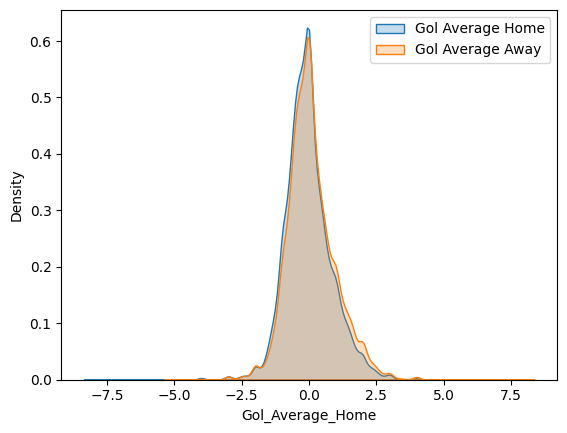

In [91]:
columnas = ['Gol Average Home','Gol Average Away']
for i, col in enumerate(gol_averages.columns):
    sns.kdeplot(gol_averages[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

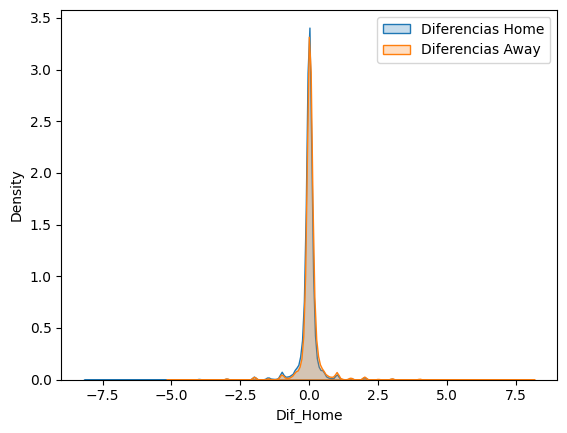

In [92]:
columnas = ['Diferencias Home','Diferencias Away']
for i, col in enumerate(diferencias.columns):
    sns.kdeplot(diferencias[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

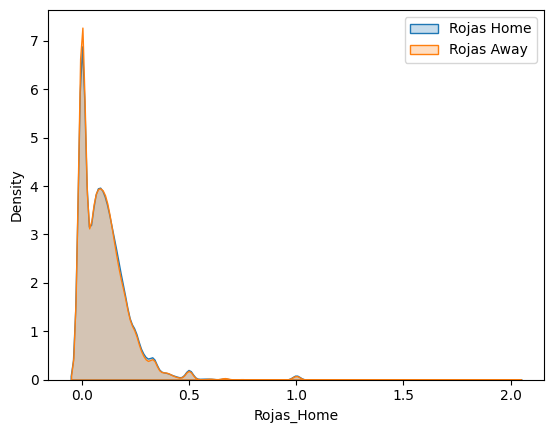

In [93]:
columnas = ['Rojas Home','Rojas Away']
for i, col in enumerate(rojas.columns):
    sns.kdeplot(rojas[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

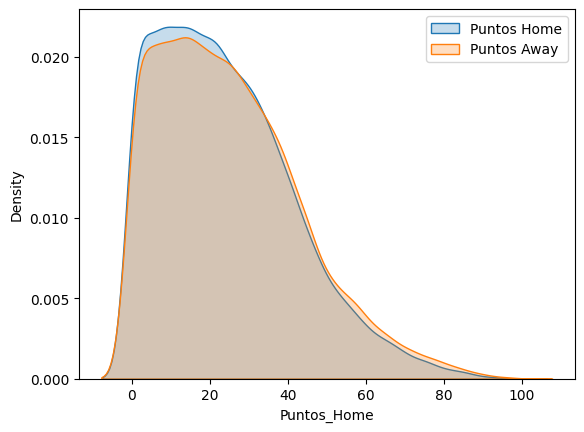

In [94]:
columnas = ['Puntos Home','Puntos Away']
for i, col in enumerate(puntos.columns):
    sns.kdeplot(puntos[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

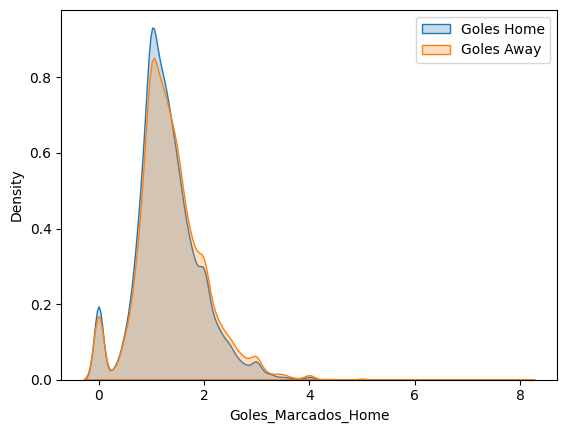

In [95]:
columnas = ['Goles Home','Goles Away']
for i, col in enumerate(goles.columns):
    sns.kdeplot(goles[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

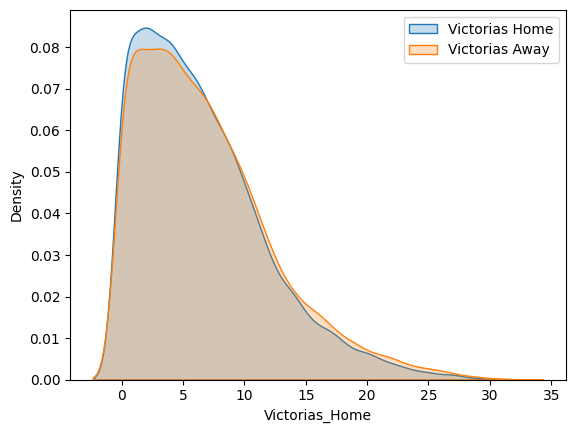

In [96]:
columnas = ['Victorias Home','Victorias Away']
for i, col in enumerate(victorias.columns):
    sns.kdeplot(victorias[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

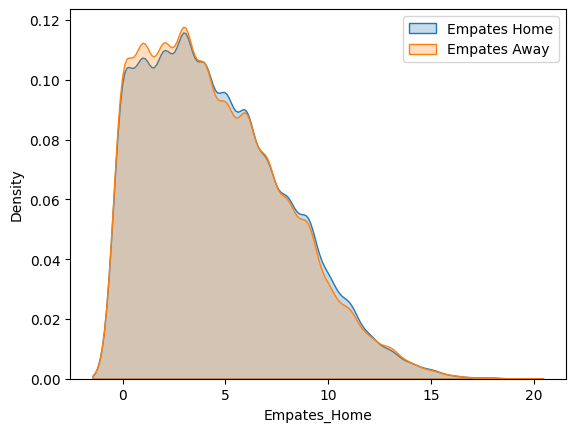

In [97]:
columnas = ['Empates Home','Empates Away']
for i, col in enumerate(empates.columns):
    sns.kdeplot(empates[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

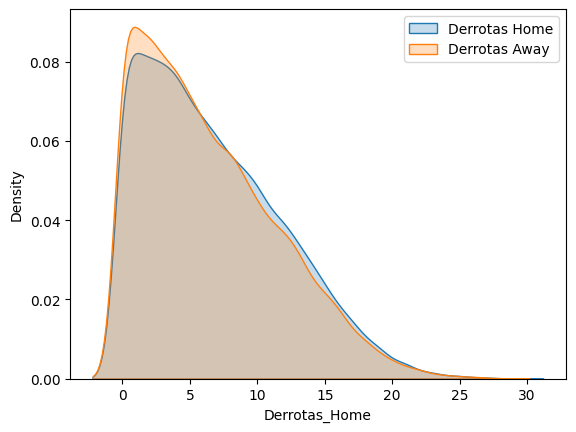

In [98]:
columnas = ['Derrotas Home','Derrotas Away']
for i, col in enumerate(derrotas.columns):
    sns.kdeplot(derrotas[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

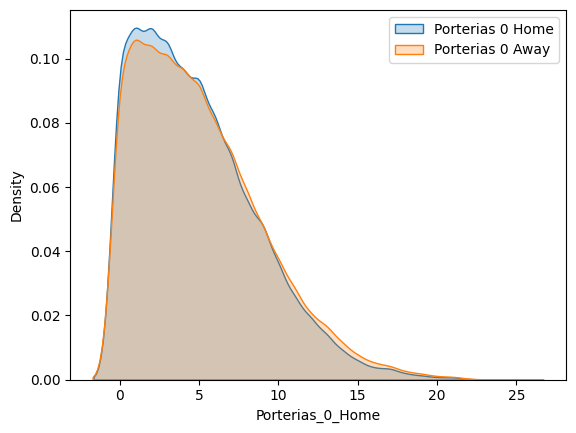

In [99]:
columnas = ['Porterias 0 Home','Porterias 0 Away']
for i, col in enumerate(porterias_0.columns):
    sns.kdeplot(porterias_0[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

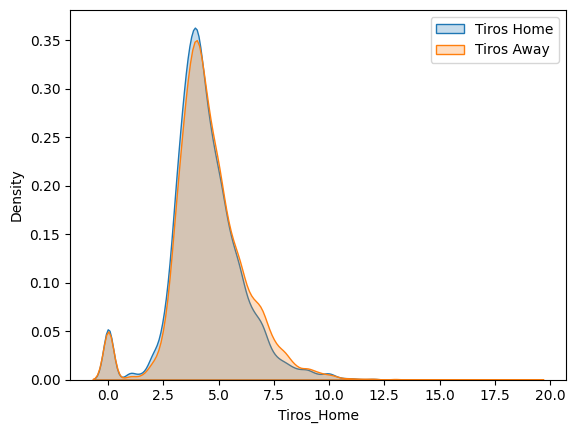

In [100]:
columnas = ['Tiros Home','Tiros Away']
for i, col in enumerate(tiros.columns):
    sns.kdeplot(tiros[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

In [101]:
scale = MinMaxScaler().fit(features)
features_normalized = scale.transform(features)
features_normalized_dataframe = pd.DataFrame(features_normalized, columns=columnas_features)
features_normalized_dataframe.head()

,Gol_Average_Home,Gol_Average_Away,Dif_Home,Dif_Away,Rojas_Home,Rojas_Away,Puntos_Home,Puntos_Away,Goles_Marcados_Home,Goles_Marcados_Away,Victorias_Home,Empates_Home,Derrotas_Home,Victorias_Away,Empates_Away,Derrotas_Away,Porterias_0_Home,Porterias_0_Away,Tiros_Home,Tiros_Away
0,0.571429,0.384615,0.615385,0.384615,0.0,0.0,0.000000,0.00,0.000000,0.000,0.0,0.000000,0.000000,0.00000,0.0,0.000000,0.0,0.0,0.000000,0.000000
1,0.571429,0.384615,0.615385,0.384615,0.0,0.0,0.000000,0.00,0.000000,0.000,0.0,0.000000,0.000000,0.00000,0.0,0.000000,0.0,0.0,0.000000,0.000000
2,0.571429,0.384615,0.615385,0.384615,0.0,0.0,0.000000,0.00,0.000000,0.000,0.0,0.000000,0.000000,0.00000,0.0,0.000000,0.0,0.0,0.000000,0.000000
3,0.500000,0.461538,0.538462,0.461538,0.0,0.0,0.000000,0.03,0.166667,0.250,0.0,0.000000,0.034483,0.03125,0.0,0.000000,0.0,0.0,0.200000,0.315789
4,0.571429,0.230769,0.615385,0.230769,0.0,0.0,0.010101,0.00,0.166667,0.125,0.0,0.052632,0.000000,0.00000,0.0,0.035714,0.0,0.0,0.333333,0.157895


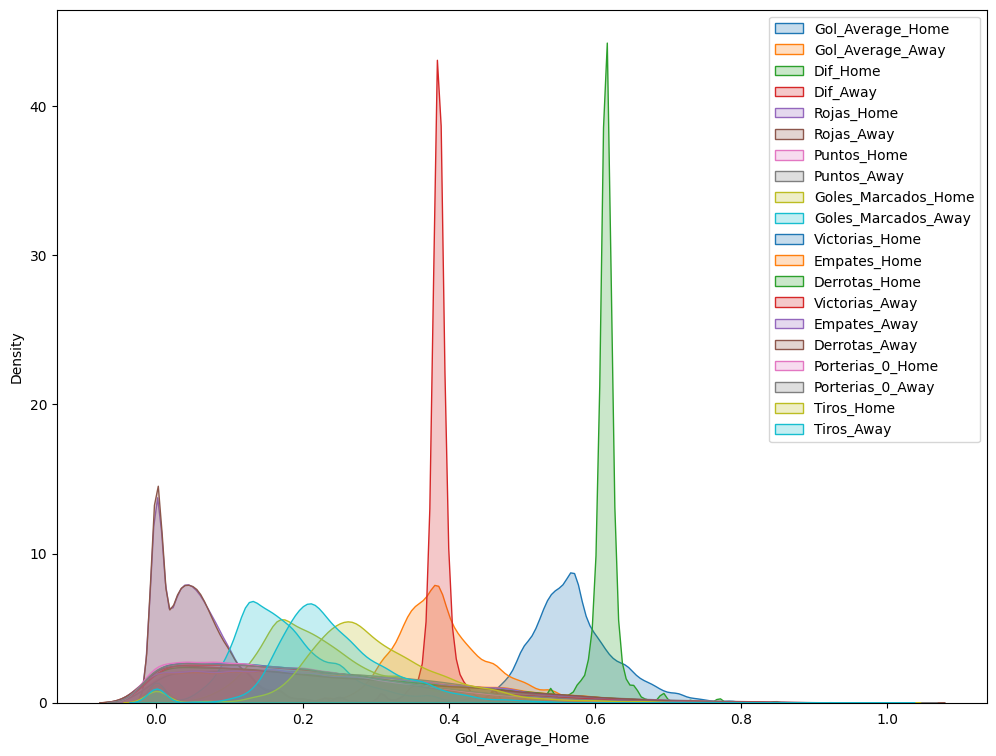

In [102]:
plt.figure(figsize=(12, 9))
for i, col in enumerate(features_normalized_dataframe.columns):
    sns.kdeplot(features_normalized_dataframe[col], fill=True, label=columnas_features[i])
plt.legend()
plt.show()

In [103]:
onehot_encoder = OneHotEncoder(sparse_output=False)
equipos_encoded = onehot_encoder.fit_transform(np.array([equipos_locales, equipos_visitantes]).T)
equipos_encoded.shape

(16803, 394)

In [104]:
#predictores = np.concatenate([gol_average_home,gol_average_away,diferencia_home,diferencia_away,rojas_home,rojas_away], axis=1)
predictores = np.concatenate((features_normalized_dataframe[columnas_features].values, equipos_encoded), axis=1)

In [105]:
predictores.shape

(16803, 414)

## - Entrenamiento del modelo

### División del dataset en entrenamiento y evaluación del modelo

In [106]:
features_train, features_test, target_train, target_test = train_test_split( predictores, target, test_size=0.2, random_state=42)
print ('Train set:', features_train.shape,  target_train.shape)
print ('Test set:', features_test.shape,  target_test.shape)

Train set: (13442, 414) (13442,)
Test set: (3361, 414) (3361,)


### Definición y construcción del modelo

In [107]:
def get_modelo_regresion():
    model = LogisticRegression(max_iter=3000, solver='liblinear')
    return model

def get_modelo_random_forest():
    model = RandomForestClassifier(n_estimators=300, random_state=42, max_depth=6, criterion='log_loss')
    return model

def get_modelo_svc():
    model = SVC(kernel='linear', C=0.5, gamma='scale', probability=True)
    return model

def get_modelo_gbm(): ##mejores resultados pero tarda en entrenar
    model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)  
    return model

def get_modelo_decision_tree():
    model = DecisionTreeClassifier(criterion="log_loss",max_depth=13, random_state=42) 
    return model

def get_modelo_knn(): ##mejor recall en empates
    model = KNeighborsClassifier(n_neighbors=47, metric="minkowski", weights='uniform')
    return model

def get_modelo_naive_bayes():
    #model = GaussianNB()
    model = MultinomialNB()
    return model

model = get_modelo_regresion()

### Entrenamiento del modelo

In [108]:
model.fit(features_train, target_train)
#iteraciones=4
#historial_entrenamiento=model.fit(features_train, target_train, validation_data=(features_test,target_test), epochs=iteraciones, verbose=1)

LogisticRegression(max_iter=3000, solver='liblinear')

## -Evaluación del modelo

### Evolución del modelo

In [109]:
target_pred = model.predict(features_test)
accuracy = accuracy_score(target_test, target_pred)
recal = recall_score(target_test, target_pred, average=None)
recal_total = recall_score(target_test, target_pred, average='macro')
precision = precision_score(target_test, target_pred, average=None)
precision_total = precision_score(target_test, target_pred, average='macro')
conf_matrix = confusion_matrix(target_test, target_pred)
print("Accuracy del modelo:", accuracy)
print("Recall del modelo:", recal)
print("Recall del modelo:", recal_total)
print("Precision del modelo:", precision)
print("Precision del modelo:", precision_total)
print("Matriz de Confusión:")
print(conf_matrix)

Accuracy del modelo: 0.7432311811960726
Recall del modelo: [0.67417062 0.81291094]
Recall del modelo: 0.7435407772738476
Precision del modelo: [0.7842867  0.71204188]
Precision del modelo: 0.748164291822574
Matriz de Confusión:
[[1138  550]
 [ 313 1360]]


ValueError: The number of FixedLocator locations (85), usually from a call to set_ticks, does not match the number of labels (7).

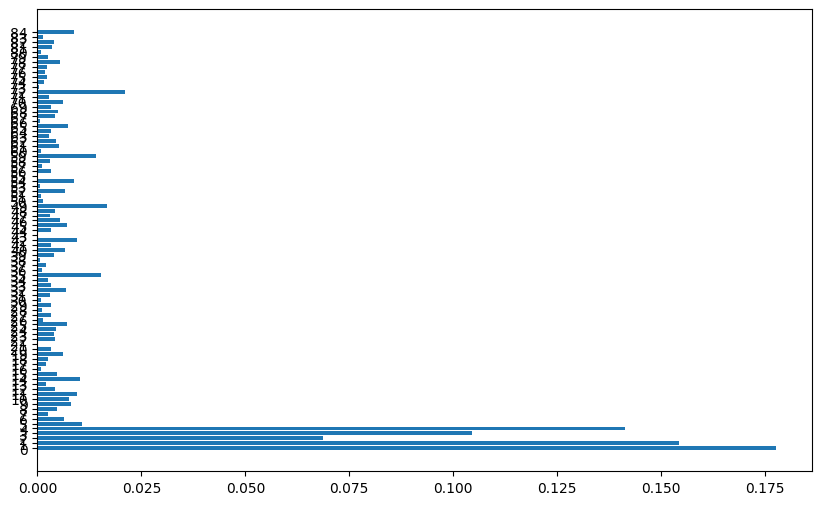

In [273]:
importances = model.feature_importances_

# Obtener nombres de las características
nombres_caracteristicas = ['GAH','GAA','RH','GH','GA','HT','AT']

# Crear un gráfico de barras para visualizar la importancia de las características
plt.figure(figsize=(10, 6))
plt.barh(range(len(importances)), importances, align='center')
plt.yticks(range(len(importances)), nombres_caracteristicas)
plt.xlabel('Importancia de las características')
plt.ylabel('Características')
plt.title('Importancia de las características en Random Forest')
plt.show()

## - Predicción real de un partido

In [142]:
'''
HT='Barcelona'
AT='Malaga'
datos_partido_a_predecir=datos_partidos.loc[(datos_partidos['HomeTeam']==HT) & (datos_partidos['AwayTeam']==AT)]
print(datos_partido_a_predecir.shape)
print(datos_partido_a_predecir)
'''
HT='Real Madrid'
AT='Osasuna'
gol_average_home = dict_ultimo_gol_average_equipo[HT]
gol_average_away = dict_ultimo_gol_average_equipo[AT]
dif_home = dict_ultimas_diferencias_cada_equipo[HT]
dif_away = dict_ultimas_diferencias_cada_equipo[AT]
rojas_home = dict_ultimas_rojas_cada_equipo[HT]
rojas_away = dict_ultimas_rojas_cada_equipo[AT]

### Normalizar los predictores teniendo en cuenta los predictores usados para el entrenamiento del modelo

In [143]:
local = [HT,]
visitante = [AT,]
locales_encoded = label_encoder.transform(local)
visitantes_encoded = label_encoder.transform(visitante)

equipos_encoded = onehot_encoder.transform(np.array([locales_encoded, visitantes_encoded]).T)
equipos_encoded.shape

(1, 80)

In [144]:
datos_partido = np.array([
    gol_average_home, gol_average_away,
    dif_home, dif_away,
    rojas_home, rojas_away
]).reshape(1, -1)
datos_partido = scale.transform(datos_partido)
datos_partido.shape

c:\Users\User\OneDrive\Escritorio\Cosas_TFG\.venv\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


(1, 6)

In [145]:
predictores = np.concatenate((datos_partido, equipos_encoded), axis=1)
predictores.shape

(1, 86)

### Predicción del valor objetivo

In [146]:
pred1 = model.predict_proba(predictores)
pred1

array([[0.12339029, 0.19494218, 0.68166753]])

### Conversión del número devuelto
Puede que el valor de las probabilidades devuelto por el modelo sea muy pequeño así que se opera para ser un número más manejable

In [147]:
def convertir_numbero(prediccion: list) -> list:
    prediccion_valores=[]
    for i in range(len(prediccion[0])):
      pred_number=float(format(prediccion[0][i], '.3f'))
      prediccion_valores.append(pred_number)

    return (prediccion_valores)
  
pred1_number_probabilities=convertir_numbero(pred1)

### Obtención del resultado predicho en base a las probabilidades predichas por el modelo

In [148]:
def get_ganador_prediccion(ganador: list) -> str:
    y=ganador.index(max(ganador))
    if y==0:
        pred_winner='Away'
    elif y==1:
        pred_winner='Draw'
    else:
        pred_winner='Home'
    return pred_winner

ganador_predicho=get_ganador_prediccion(pred1_number_probabilities)

### Resultado Final

In [149]:
#print('El ganador real es: ', ganador_real)
print('El ganador predicho es: ',ganador_predicho)

El ganador predicho es:  Home


### Visualización de las probabilidades en una gráfica

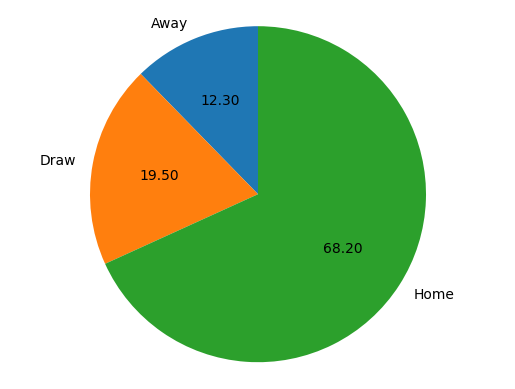

In [150]:
etiquetas = 'Away', 'Draw', 'Home'
figureObject, axesObject = plt.subplots()
axesObject.pie(pred1_number_probabilities, labels=etiquetas, autopct='%1.2f', startangle=90)
axesObject.axis('equal') # Aspect ratio equal means pie is a circle
plt.show()